# EEE 10 Stage High Pressure Compressor (HPC)

EEE stands for Energy Efficient Engine, initiated in the mid-1970s. It was aimed at developing a more fuel efficient turbofan engine for commercial aviation. Both Pratt and Whitney and General Electric developed versions of the engine with various components.

This notebook demonstrates the turbo-design model for the EEE 10-stage High Pressure Compressor (HPC). The geometry and simulation data come from NASA reports and publications.

## Important Disclaimer

The data in this example was extracted from a publication in 1982 and was scanned at some point. The document quality is poor and hard to read. Without the original code used to generate the E3 spreadsheet or CFD results from the 1980s, this work falls under the category of 'trust me bro'.

**Note on Massflow**: The massflow values in this model may not match the published values exactly due to uncertainties in the loss models and boundary conditions extracted from the aged documentation.

## Design Point Operating Conditions

| **Parameter** | **Units** | **Value** |
|:-------------:|:---------:|:---------:|
| Inlet P0      | psi       | Extracted from Excel |
| Inlet T0      | R         | Extracted from Excel |
| RPM           |           | 12400 |
| Massflow      | kg/s      | 54.4 |
| Stages        |           | 10 (IGV + 10 rotor-stator pairs) |

## Installation

First, install the required packages:

In [1]:
!pip install turbo-design
!pip install pyiges[full]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 477.6/477.6 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.3/19.3 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.9/74.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.0/148.0 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.9/275.9 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 MB 7.8 MB/s eta 0:00:00


## Import Libraries

Import all necessary libraries for geometry processing, compressor design, and data analysis:

In [2]:
from turbodesign import Inlet, RowType, BladeRow, Passage, Outlet, PassageType
from turbodesign.row_factory import make_rotor_row, make_stator_row
from turbodesign.compressor_spool import CompressorSpool
from turbodesign import Coolant
from turbodesign.loss.fixedpressureloss import FixedPressureLoss
from turbodesign.deviation.fixed_deviation import FixedDeviation
from cantera import Solution
from pathlib import Path
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt

## Load Helper Functions

The example includes helper functions to load blade counts and overall performance data from the Excel spreadsheet:

In [4]:
# If running in a Colab or similar environment, clone the repo first
!git clone https://github.com/nasa/turbo-design.git
%cd turbo-design/examples/EEE-HPC

from read_overall_data import load_overall_data, load_blade_counts, compute_entropy_rise

Cloning into 'turbo-design'...
remote: Enumerating objects: 2522, done.
remote: Counting objects: 100% (430/430), done.
remote: Compressing objects: 100% (246/246), done.
remote: Total 2522 (delta 286), reused 274 (delta 182), pack-reused 2092 (from 1)
Receiving objects: 100% (2522/2522), 297.63 MiB | 25.56 MiB/s, done.
Resolving deltas: 100% (1388/1388), done.
Updating files: 100% (734/734), done.
/content/turbo-design/examples/EEE-HPC


## Load Geometry Data

The hub, shroud, and blade geometries are stored in a preprocessed pickle file. This data was extracted from IGES files and processed to fit between the hub and shroud curves:

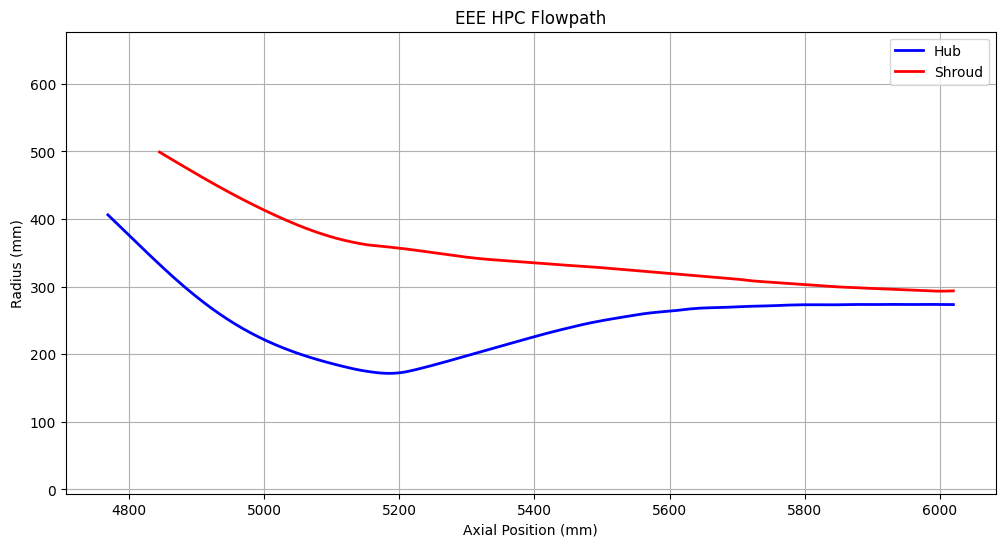

In [5]:
# Load preprocessed geometry
e3_hpc = pickle.load(open('e3_hpc_processed.pkl','rb'))
hub = e3_hpc['hub']
shroud = e3_hpc['shroud']

# Visualize the flowpath
plt.figure(figsize=(12, 6))
plt.plot(hub[:,0], hub[:,1], 'b-', linewidth=2, label='Hub')
plt.plot(shroud[:,0], shroud[:,1], 'r-', linewidth=2, label='Shroud')
plt.xlabel('Axial Position (mm)')
plt.ylabel('Radius (mm)')
plt.title('EEE HPC Flowpath')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

## Meridional View with Blades

Plot all blade rows overlaid on the flowpath in the meridional (axial-radial) plane, similar to the EEE-HPT example:

In [ ]:
# Plot blades with flowpath (meridional view)
fig, ax = plt.subplots(figsize=(16, 6))

# Plot hub and shroud
ax.plot(hub[:, 0], hub[:, 1], 'b-', linewidth=2.5, label='Hub')
ax.plot(shroud[:, 0], shroud[:, 1], 'r-', linewidth=2.5, label='Shroud (Casing)')

# Blade data columns: [x (axial), r*theta, r (radial)]
# Group blades by type for cleaner legend: IGV, Rotors, Stators
for i, blade in enumerate(e3_hpc['blades']):
    ss = blade[0]  # suction side: (nsections, npts, 3)
    ps = blade[1]  # pressure side: (nsections, npts, 3)

    if i == 0:
        color, label = '#9b59b6', 'IGV'
    elif i % 2 == 1:  # Rotor indices: 1, 3, 5, ...
        color = '#e74c3c'
        label = 'Rotors' if i == 1 else None
    else:  # Stator indices: 2, 4, 6, ...
        color = '#2ecc71'
        label = 'Stators' if i == 2 else None

    for j in range(ss.shape[0]):
        ax.plot(ss[j, :, 0], ss[j, :, 2], '.', color=color,
                markersize=0.5, alpha=0.5, label=label if j == 0 else None)
        ax.plot(ps[j, :, 0], ps[j, :, 2], '.', color=color,
                markersize=0.5, alpha=0.5)

ax.set_xlabel('Axial Position (mm)', fontsize=16)
ax.set_ylabel('Radial Position (mm)', fontsize=16)
ax.set_title('EEE 10-Stage HPC Meridional View with Blades', fontsize=18, fontweight='bold')
ax.legend(loc='upper right', fontsize=12, framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_aspect('equal', adjustable='box')
ax.tick_params(axis='both', labelsize=12)
ax.minorticks_on()
ax.grid(which='minor', linestyle=':', alpha=0.3)
fig.tight_layout()
plt.show()

## Load Operating Conditions from Excel

The `E3_HPC_Overall_Data.xlsx` file contains streamline-wise performance data extracted from NASA publications. This includes:
- Total pressure and temperature at inlet and exit of each blade row
- Metal angles (beta)
- Loss coefficients
- Deviation angles

The data is organized by component (inlet, IGV, rotor1, stator1, ..., rotor10, stator10).

In [6]:
workbook_path = Path('E3_HPC_Overall_Data.xlsx')

# Load overall performance data (automatically converts psi to Pa, Rankine to Kelvin)
excel_data = load_overall_data(
    workbook_path,
    sheet_name=None,
    loss_sheet_name="Detailed Report Data",
    convert_units=True,
)

# Load blade counts for each row
blade_counts = load_blade_counts(workbook_path)

print("Loaded data for components:")
for key in excel_data.keys():
    print(f"  {key}: {len(excel_data[key])} streamlines, {blade_counts.get(key, 'N/A')} blades")

Loaded data for components:
  inlet: 12 streamlines, N/A blades
  rotor1: 12 streamlines, 28 blades
  stator1: 12 streamlines, 50 blades
  rotor2: 12 streamlines, 38 blades
  stator2: 12 streamlines, 50 blades
  rotor3: 12 streamlines, 68 blades
  stator3: 12 streamlines, 82 blades
  rotor4: 12 streamlines, 60 blades
  stator4: 12 streamlines, 92 blades
  rotor5: 12 streamlines, 70 blades
  stator5: 12 streamlines, 110 blades
  rotor6: 12 streamlines, 80 blades
  stator6: 12 streamlines, 120 blades
  rotor7: 12 streamlines, 82 blades
  stator7: 12 streamlines, 112 blades
  rotor8: 12 streamlines, 84 blades
  stator8: 12 streamlines, 104 blades
  rotor9: 12 streamlines, 88 blades
  stator9: 12 streamlines, 118 blades
  rotor10: 12 streamlines, 96 blades
  stator10: 12 streamlines, 130 blades


## Setup Boundary Conditions

Extract inlet total pressure and temperature from the Excel data:

In [7]:
P0 = excel_data['inlet']["Inlet Pt"].mean()
T0 = excel_data['inlet']["TT Exit"].mean()
n_streamlines = 12

print(f"Inlet Total Pressure: {P0/1000:.2f} kPa")
print(f"Inlet Total Temperature: {T0:.2f} K")
print(f"Number of Streamlines: {n_streamlines}")

Inlet Total Pressure: 59.48 kPa
Inlet Total Temperature: 304.76 K
Number of Streamlines: 12


## Define Fluid Properties

Use Cantera to define air properties at the inlet conditions:

In [8]:
fluid = Solution('air.yaml')
fluid.TP = T0, P0
print(f"Coefficient of Pressure [J/kg-K]: {fluid.cp:0.4f}")
print(f"Gas Constant [J/kg-K]: {fluid.cp - fluid.cv:0.4f}")
print(f"Gamma: {fluid.cp / fluid.cv:0.4f}")

Coefficient of Pressure [J/kg-K]: 1003.5426
Gas Constant [J/kg-K]: 287.0025
Gamma: 1.4005


## Define Inlet and Outlet Boundary Conditions

The inlet uses total pressure and temperature distributions from the Excel data. The outlet uses total pressure at the exit of the last stator:

In [9]:
inlet = Inlet(hub_location=0, shroud_location=0, alpha=[0])
inlet.init_total(
    P0=excel_data['inlet']["Inlet Pt"].to_numpy().tolist(),
    T0=excel_data['inlet']["TT Exit"].to_numpy().tolist(),
    M=excel_data['inlet']["Ma Inlet"].to_numpy().tolist()
)

outlet = Outlet(num_streamlines=n_streamlines)
outlet.init_total(
    P0=excel_data['stator10']['PT Exit'].mean(),
    percent_radii=[0.5]
)

## Understanding the IGV (Inlet Guide Vane)

The Inlet Guide Vane (IGV) is the first stationary blade row that:
- Pre-swirls the flow before it enters the first rotor
- Improves the incidence angle on the rotor blades
- Helps control the loading distribution across the compressor

In turbo-design, the IGV is treated as a special type of stator with `row_type = RowType.IGV`.

## Calculate Blade Row Positioning

Each blade row exit location is calculated as the midpoint between adjacent blade trailing edges, expressed as a fraction of the total flowpath length:

In [10]:
# Calculate axial chord for each blade
cax_arr = []
for blade in e3_hpc['blades']:
    ss = blade[0]; ps = blade[1]
    cax1 = (ss[0,:,0].max()-ss[0,:,0].min())/1000
    cax2 = (ps[0,:,0].max()-ps[0,:,0].min())/1000
    cax_arr.append(max([cax1,cax2]))

# Calculate exit locations as percentage along hub and shroud
hub_exit_locations = []
shroud_exit_locations = []

for i in range(1, len(e3_hpc['blades'])):
    prev_blade = e3_hpc['blades'][i-1]
    blade = e3_hpc['blades'][i]

    hub_exit = ((prev_blade[0][0,:,0].max() + blade[0][0,:,0].min())/2 - hub[:,0].min()) / (hub[:,0].max() - hub[:,0].min())
    hub_exit_locations.append(hub_exit)

    shroud_exit = ((prev_blade[0][-1,:,0].max() + blade[0][-1,:,0].min())/2 - shroud[:,0].min()) / (shroud[:,0].max() - shroud[:,0].min())
    shroud_exit_locations.append(shroud_exit)

# Last blade exit
lastblade = e3_hpc['blades'][-1]
hub_exit_locations.append((lastblade[0][0,:,0].max() - hub[:,0].min()) / (hub[:,0].max() - hub[:,0].min()))
shroud_exit_locations.append((lastblade[0][-1,:,0].max() - shroud[:,0].min()) / (shroud[:,0].max() - shroud[:,0].min()))

print(f"IGV exit location: {hub_exit_locations[0]:.3f}")
print(f"Last stator exit location: {hub_exit_locations[-1]:.3f}")

IGV exit location: 0.354
Last stator exit location: 0.992


## Create Blade Rows

Now we create all blade rows using the row factory functions. The IGV is created first, followed by 10 rotor-stator pairs:

In [11]:
# IGV (Inlet Guide Vane)
IGV1 = make_stator_row(hub_location=hub_exit_locations[0])
IGV1.row_type = RowType.IGV
IGV1.stage_id = 1
IGV1.num_blades = blade_counts.get("igv", IGV1.num_blades)
IGV1.axial_chord = cax_arr[0]

# Stage 1
rotor1 = make_rotor_row(hub_location=hub_exit_locations[1])
rotor1.stage_id = 1
rotor1.num_blades = blade_counts.get("rotor1", rotor1.num_blades)
rotor1.axial_chord = cax_arr[1]

stator1 = make_stator_row(hub_location=hub_exit_locations[2])
stator1.stage_id = 1
stator1.num_blades = blade_counts.get("stator1", stator1.num_blades)
stator1.axial_chord = cax_arr[2]

# Stage 2
rotor2 = make_rotor_row(hub_location=hub_exit_locations[3])
rotor2.stage_id = 2
rotor2.num_blades = blade_counts.get("rotor2", rotor2.num_blades)
rotor2.axial_chord = cax_arr[3]

stator2 = make_stator_row(hub_location=hub_exit_locations[4])
stator2.stage_id = 2
stator2.num_blades = blade_counts.get("stator2", stator2.num_blades)
stator2.axial_chord = cax_arr[4]

# Stage 3
rotor3 = make_rotor_row(hub_location=hub_exit_locations[5])
rotor3.stage_id = 3
rotor3.num_blades = blade_counts.get("rotor3", rotor3.num_blades)
rotor3.axial_chord = cax_arr[5]

stator3 = make_stator_row(hub_location=hub_exit_locations[6])
stator3.shroud_location = shroud_exit_locations[6]
stator3.stage_id = 3
stator3.num_blades = blade_counts.get("stator3", stator3.num_blades)
stator3.axial_chord = cax_arr[6]

# Stage 4
rotor4 = make_rotor_row(hub_location=hub_exit_locations[7])
rotor4.stage_id = 4
rotor4.num_blades = blade_counts.get("rotor4", rotor4.num_blades)
rotor4.axial_chord = cax_arr[7]

stator4 = make_stator_row(hub_location=hub_exit_locations[8])
stator4.stage_id = 4
stator4.num_blades = blade_counts.get("stator4", stator4.num_blades)
stator4.axial_chord = cax_arr[8]

# Stage 5
rotor5 = make_rotor_row(hub_location=hub_exit_locations[9])
rotor5.stage_id = 5
rotor5.num_blades = blade_counts.get("rotor5", rotor5.num_blades)
rotor5.axial_chord = cax_arr[9]

stator5 = make_stator_row(hub_location=hub_exit_locations[10])
stator5.stage_id = 5
stator5.num_blades = blade_counts.get("stator5", stator5.num_blades)
stator5.axial_chord = cax_arr[10]

# Stage 6
rotor6 = make_rotor_row(hub_location=hub_exit_locations[11])
rotor6.stage_id = 6
rotor6.num_blades = blade_counts.get("rotor6", rotor6.num_blades)
rotor6.axial_chord = cax_arr[11]

stator6 = make_stator_row(hub_location=hub_exit_locations[12])
stator6.stage_id = 6
stator6.num_blades = blade_counts.get("stator6", stator6.num_blades)
stator6.axial_chord = cax_arr[12]

# Stage 7
rotor7 = make_rotor_row(hub_location=hub_exit_locations[13])
rotor7.shroud_location = shroud_exit_locations[13]
rotor7.stage_id = 7
rotor7.num_blades = blade_counts.get("rotor7", rotor7.num_blades)
rotor7.axial_chord = cax_arr[13]

stator7 = make_stator_row(hub_location=hub_exit_locations[14])
stator7.stage_id = 7
stator7.num_blades = blade_counts.get("stator7", stator7.num_blades)
stator7.axial_chord = cax_arr[14]

# Stage 8
rotor8 = make_rotor_row(hub_location=hub_exit_locations[15])
rotor8.stage_id = 8
rotor8.num_blades = blade_counts.get("rotor8", rotor8.num_blades)
rotor8.axial_chord = cax_arr[15]

stator8 = make_stator_row(hub_location=hub_exit_locations[16])
stator8.stage_id = 8
stator8.num_blades = blade_counts.get("stator8", stator8.num_blades)
stator8.axial_chord = cax_arr[16]

# Stage 9
rotor9 = make_rotor_row(hub_location=hub_exit_locations[17])
rotor9.shroud_location = shroud_exit_locations[17]
rotor9.stage_id = 9
rotor9.num_blades = blade_counts.get("rotor9", rotor9.num_blades)
rotor9.axial_chord = cax_arr[17]

stator9 = make_stator_row(hub_location=hub_exit_locations[18])
stator9.shroud_location = shroud_exit_locations[18]
stator9.stage_id = 9
stator9.num_blades = blade_counts.get("stator9", stator9.num_blades)
stator9.axial_chord = cax_arr[18]

# Stage 10
rotor10 = make_rotor_row(hub_location=hub_exit_locations[19])
rotor10.stage_id = 10
rotor10.num_blades = blade_counts.get("rotor10", rotor10.num_blades)
rotor10.axial_chord = cax_arr[19]

stator10 = make_stator_row(hub_location=hub_exit_locations[20])
stator10.stage_id = 10
stator10.num_blades = blade_counts.get("stator10", stator10.num_blades)
stator10.axial_chord = cax_arr[20]

print("Created 21 blade rows: 1 IGV + 10 rotor-stator pairs")

Created 21 blade rows: 1 IGV + 10 rotor-stator pairs


## Assign Metal Blade Angles (Beta)

The metal angles are extracted from the Excel "Beta" columns. For rotors, negative angles indicate rotation in the opposite direction:

In [12]:
def load_beta_column_from_detailed_report(workbook, beta_occurrence=0):
    """Extract beta columns from the Detailed Report Data sheet."""
    sheet = pd.read_excel(workbook, sheet_name="Detailed Report Data", header=0)
    header_row = sheet.iloc[0]
    beta_cols = [idx for idx, value in enumerate(header_row)
                 if isinstance(value, str) and value.strip().lower() == "beta"]
    if beta_occurrence >= len(beta_cols):
        return {}
    beta_idx = beta_cols[beta_occurrence]
    sl_series = pd.to_numeric(sheet.iloc[:, 1], errors="coerce")
    reset_indices = [i for i, val in enumerate(sl_series) if val == 1]
    if not reset_indices:
        return {}
    reset_indices.append(len(sheet))
    labels = ["inlet"]
    for stage in range(1, 11):
        labels.extend([f"rotor{stage}", f"stator{stage}"])

    beta_lookup = {}
    for block_idx, start in enumerate(reset_indices[:-1]):
        if block_idx >= len(labels):
            break
        end = reset_indices[block_idx + 1]
        series = pd.to_numeric(sheet.iloc[start:end, beta_idx], errors="coerce").dropna()
        if series.empty:
            continue
        beta_lookup[labels[block_idx]] = series.tolist()
    return beta_lookup

beta1_lookup = load_beta_column_from_detailed_report(workbook_path, beta_occurrence=0)

def set_beta_metal(row, key):
    """Set beta1_metal and beta2_metal from Excel data."""
    df = excel_data.get(key)
    beta_exit_col = None
    beta_inlet_col = None
    if df is not None:
        if "Beta" in df.columns:
            beta_inlet_col = "Beta"
        if beta_inlet_col is None and "Unnamed: 9" in df.columns:
            beta_inlet_col = "Unnamed: 9"
        if "Beta.1" in df.columns:
            beta_exit_col = "Beta.1"
        elif beta_inlet_col is not None:
            beta_exit_col = beta_inlet_col

    def _prepare_beta(values, rotor_negative=False):
        series = values if isinstance(values, pd.Series) else pd.Series(values)
        beta_vals = pd.to_numeric(series, errors="coerce").dropna().tolist()
        trimmed = beta_vals[:n_streamlines]
        if rotor_negative and row.row_type == RowType.Rotor:
            return [-abs(val) for val in trimmed]
        if row.row_type == RowType.IGV:
            return trimmed
        return trimmed

    if df is not None and beta_exit_col:
        exit_vals = _prepare_beta(df[beta_exit_col], rotor_negative=True)
        if exit_vals:
            row.beta2_metal = exit_vals

    inlet_vals = None
    beta1_vals = beta1_lookup.get(key)
    if beta1_vals:
        inlet_vals = _prepare_beta(beta1_vals)
    elif df is not None and beta_inlet_col:
        inlet_vals = _prepare_beta(df[beta_inlet_col])

    if inlet_vals:
        row.beta1_metal = inlet_vals

# Apply to all rows
set_beta_metal(IGV1, "inlet")
set_beta_metal(rotor1, "rotor1")
set_beta_metal(stator1, "stator1")
set_beta_metal(rotor2, "rotor2")
set_beta_metal(stator2, "stator2")
set_beta_metal(rotor3, "rotor3")
set_beta_metal(stator3, "stator3")
set_beta_metal(rotor4, "rotor4")
set_beta_metal(stator4, "stator4")
set_beta_metal(rotor5, "rotor5")
set_beta_metal(stator5, "stator5")
set_beta_metal(rotor6, "rotor6")
set_beta_metal(stator6, "stator6")
set_beta_metal(rotor7, "rotor7")
set_beta_metal(stator7, "stator7")
set_beta_metal(rotor8, "rotor8")
set_beta_metal(stator8, "stator8")
set_beta_metal(rotor9, "rotor9")
set_beta_metal(stator9, "stator9")
set_beta_metal(rotor10, "rotor10")
set_beta_metal(stator10, "stator10")

# IGV behaves like a stator for absolute angles
if IGV1.beta1.size:
    IGV1.alpha1 = IGV1.beta1.copy()
if IGV1.beta2.size:
    IGV1.alpha2 = IGV1.beta2.copy()

print("Assigned metal blade angles from Excel data")

Assigned metal blade angles from Excel data


## Assign Loss Models

Loss coefficients are extracted from the Excel "Loss" column. These represent total pressure loss:

$$P_{0,Loss} = \frac{P_{01} - P_{02}}{P_{01} - P_2}$$

where subscript "0" denotes total conditions, "1" is upstream, and "2" is downstream.

In [13]:
def set_loss_model(row, key):
    """Assign FixedPressureLoss model from Excel Loss column."""
    df = excel_data.get(key)
    if df is None or "Loss" not in df.columns:
        return
    loss_vals = pd.to_numeric(df["Loss"], errors="coerce").to_numpy()
    if loss_vals.size == 0:
        return
    row.loss_model = FixedPressureLoss(loss_vals)

set_loss_model(IGV1, "inlet")
set_loss_model(rotor1, "rotor1")
set_loss_model(stator1, "stator1")
set_loss_model(rotor2, "rotor2")
set_loss_model(stator2, "stator2")
set_loss_model(rotor3, "rotor3")
set_loss_model(stator3, "stator3")
set_loss_model(rotor4, "rotor4")
set_loss_model(stator4, "stator4")
set_loss_model(rotor5, "rotor5")
set_loss_model(stator5, "stator5")
set_loss_model(rotor6, "rotor6")
set_loss_model(stator6, "stator6")
set_loss_model(rotor7, "rotor7")
set_loss_model(stator7, "stator7")
set_loss_model(rotor8, "rotor8")
set_loss_model(stator8, "stator8")
set_loss_model(rotor9, "rotor9")
set_loss_model(stator9, "stator9")
set_loss_model(rotor10, "rotor10")
set_loss_model(stator10, "stator10")

print("Assigned loss models to all blade rows")

Assigned loss models to all blade rows


## Assign Deviation Models

Deviation represents the difference between the metal exit angle and the flow exit angle:

$$\delta = \beta_{flow} - \beta_{metal}$$

The deviation values are extracted from the Excel "Deviation" column and applied using a fixed deviation model.

In [14]:
def set_deviation_model(row, key):
    """Assign FixedDeviation model from Excel Deviation column."""
    df = excel_data.get(key)
    if df is None or "Deviation" not in df.columns:
        return
    dev_vals = pd.to_numeric(df["Deviation"], errors="coerce").to_numpy()
    if dev_vals.size == 0:
        return
    row.deviation_function = FixedDeviation(dev_vals)

set_deviation_model(IGV1, "inlet")
set_deviation_model(rotor1, "rotor1")
set_deviation_model(stator1, "stator1")
set_deviation_model(rotor2, "rotor2")
set_deviation_model(stator2, "stator2")
set_deviation_model(rotor3, "rotor3")
set_deviation_model(stator3, "stator3")
set_deviation_model(rotor4, "rotor4")
set_deviation_model(stator4, "stator4")
set_deviation_model(rotor5, "rotor5")
set_deviation_model(stator5, "stator5")
set_deviation_model(rotor6, "rotor6")
set_deviation_model(stator6, "stator6")
set_deviation_model(rotor7, "rotor7")
set_deviation_model(stator7, "stator7")
set_deviation_model(rotor8, "rotor8")
set_deviation_model(stator8, "stator8")
set_deviation_model(rotor9, "rotor9")
set_deviation_model(stator9, "stator9")
set_deviation_model(rotor10, "rotor10")
set_deviation_model(stator10, "stator10")

print("Assigned deviation models to all blade rows")

Assigned deviation models to all blade rows


## Pressure Ratio Calculation

In compressor design, each blade row contributes to the overall pressure ratio. The pressure ratio for each row can be calculated from the Excel data:

$$PR_{row} = \frac{P_{02}}{P_{01}}$$

The overall compressor pressure ratio is the product of all row pressure ratios:

$$PR_{overall} = \prod_{i=1}^{n} PR_i$$

## Create Passage and Compressor Spool

The passage defines the hub and shroud curves. Convert from mm to m for turbo-design:

In [15]:
hub_m = hub / 1000
shroud_m = shroud / 1000

passage = Passage(
    hub_m[:, 0], hub_m[:, 1],
    shroud_m[:, 0], shroud_m[:, 1],
    passageType=PassageType.Axial
)

rows = [
    IGV1, rotor1, stator1, rotor2, stator2,
    rotor3, stator3, rotor4, stator4,
    rotor5, stator5, rotor6, stator6,
    rotor7, stator7, rotor8, stator8,
    rotor9, stator9, rotor10, stator10
]

spool = CompressorSpool(
    passage=passage,
    massflow=54.4, # Note the error you see is because of this massflow.
    inlet=inlet,
    outlet=outlet,
    rows=rows,
    rpm=12400,
    num_streamlines=12,
    fluid=fluid
)
# Note: The massflow 54.4 comes from publications. The iges files do not match the publications.
#   Some say the hub and shroud should be scaled to match publications. Truth is, I dont know.
#   The people who worked on this have all retired. This was done before I was born.
#   If anyone has the original files or knows what it should be please let me know. I can send you some chocolates

spool.adjust_streamlines = False
print("Created CompressorSpool with 21 blade rows")

Created CompressorSpool with 21 blade rows


## Solve the Compressor Model

Now we solve the 1D meanline model. This iterates to balance massflow and satisfies the radial equilibrium equations:

In [16]:
spool.solve()
print("\nCompressor solution completed!")
print(f"Inlet massflow: {inlet.total_massflow:.2f} kg/s")
print(f"Outlet total pressure: {outlet.P0.mean()/1000:.2f} kPa")

Using pressure balance mode: blade exit angles are fixed, total pressures will be adjusted
Looping to converge massflow (compressor)


Exception: Invalid value of C 4.78 which causes Vm to be nan.
Change reduce alpha/beta for RowType.Rotor 2

## Export Results

Export the detailed results to a JSON file for further analysis:

In [ ]:
spool.export_properties("E3-HPC-Results.json")
print("Results exported to E3-HPC-Results.json")

## Visualize Results

Generate plots of the flowpath and velocity triangles:

In [ ]:
spool.plot()
plt.show()

In [ ]:
spool.plot_velocity_triangles()
plt.show()

## Summary

This notebook demonstrated:
1. Loading geometry and performance data for the EEE 10-stage HPC
2. Setting up the IGV (Inlet Guide Vane) as a special stator
3. Assigning metal angles, loss models, and deviation models from Excel data
4. Understanding pressure ratio calculations for multistage compressors
5. Solving the 1D meanline compressor model
6. Visualizing the results

### Key Takeaways:
- The IGV is a stationary blade row that pre-swirls the flow
- Loss and deviation models control the performance prediction
- The massflow may not match published values exactly due to data uncertainties
- The full radial equilibrium equations are solved to determine the flow field